In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("data/used_cars_data.csv")

In [ ]:
df.head()


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.describe()

In [ ]:
df[df["Price"].isnull()].shape

In [ ]:
df = df.dropna(subset=["Price"])

In [ ]:
df.isnull().sum()

In [ ]:
df[["Mileage", "Engine", "Power", "Seats", "New_Price"]].head(10)

In [ ]:
df[["Mileage", "Engine", "Power", "Seats", "New_Price"]].dtypes

In [ ]:
df["Mileage"] = df["Mileage"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

In [ ]:
df[["Mileage", "Fuel_Type"]].head(10)

In [ ]:
df["Engine"] = df["Engine"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

In [ ]:
df["Power"] = df["Power"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

In [ ]:
df["Power"].dtype

In [ ]:
df["Seats"].value_counts(dropna=False) #dropna tell the pandas also count nan values

In [ ]:
df["Seats"] = df["Seats"].fillna(df["Seats"].mode()[0])

In [ ]:
df.isnull().sum()

In [ ]:
df[df["Power"].isnull()][["Name", "Power", "Engine", "Fuel_Type"]].head(20)

In [ ]:
df["Power"] = df["Power"].fillna(df["Power"].median())

In [ ]:
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())


In [ ]:
df["Engine"] = df["Engine"].fillna(df["Engine"].median())

In [ ]:
df = df.drop(columns=["New_Price"])

In [ ]:
df.isnull().sum()

In [ ]:
df[["Name", "Location", "Fuel_Type", "Transmission", "Owner_Type"]].nunique()

In [ ]:
df["Brand"] = df["Name"].str.split().str[0]

In [ ]:
X = df.drop(columns=["Price"])

In [ ]:
y = df["Price"]

In [ ]:
X.head()

In [ ]:
y.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
categorical_features = ["Location", "Fuel_Type", "Transmission", "Owner_Type", "Brand"]

In [ ]:
numerical_features = ["Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats"]

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

In [ ]:
mae_scores = -cv_scores

In [ ]:
mae_scores.mean()

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = LinearRegression()

In [ ]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", linear_model)
])

In [ ]:
linear_cv_scores = cross_val_score(
    linear_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [ ]:
linear_mae_scores = -linear_cv_scores

In [ ]:
linear_mae_scores.mean()

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [ ]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [ ]:
xgb_cv_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [ ]:
xg_mae_scores = -xgb_cv_scores

In [ ]:
xg_mae_scores.mean()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10]
}

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
grid_search.best_params_

In [ ]:
-grid_search.best_score_

In [ ]:
grid_search.cv_results_["mean_test_score"]

In [ ]:
pipeline.fit(X_train,y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
test_mae = mean_absolute_error(y_test, y_pred)

In [ ]:
test_mae

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
test_r2 = r2_score(y_test, y_pred)

In [ ]:
test_r2

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5

In [ ]:
test_rmse

In [ ]:
import matplotlib.pyplot as plt

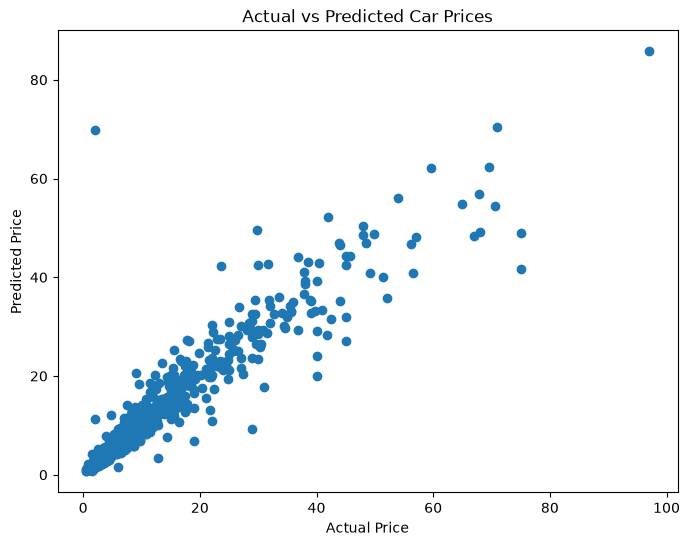

In [98]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [99]:
rf_model = pipeline.named_steps["model"]

In [100]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

In [101]:
importances = rf_model.feature_importances_

In [102]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

In [103]:
feature_importance_df.head(15)

,Feature,Importance
55,num__Power,0.656086
51,num__Year,0.153119
52,num__Kilometers_Driven,0.045502
54,num__Engine,0.037938
37,cat__Brand_Land,0.023983
53,num__Mileage,0.018621
5,cat__Location_Hyderabad,0.008270
56,num__Seats,0.008137
40,cat__Brand_Mercedes-Benz,0.005312
17,cat__Transmission_Manual,0.004790
